In [1]:
# ===============================================
# BASIC SETUP: GIT Auth and mounting google drive
# ================================================

from google.colab import drive
import sys

# Standard mount to access the config file initially
drive.mount('/content/drive')
sys.path.append('/content/drive/MyDrive/Deep-Learning-Final-Project/CNN-vs-VIT-Agribench/src')

from utils.config import initialize_project
initialize_project()

Mounted at /content/drive
Authenticated as: Ande404
Working Directory: /content/drive/MyDrive/Deep-Learning-Final-Project/CNN-vs-VIT-Agribench


In [ ]:
import os
import shutil
import random
from collections import Counter
from PIL import Image
import matplotlib.pyplot as plt

In [ ]:
seed = 42
random.seed(seed)

print(f"Seed set to {seed}")

Seed set to 42


In [ ]:
project_root = "/content/drive/MyDrive/Deep-Learning-Final-Project/CNN-vs-VIT-Agribench"

raw_dir = os.path.join(project_root, "data/raw/PlantVillage")
subset_dir = os.path.join(project_root, "data/subset/PlantVillage")
processed_dir = os.path.join(project_root, "data/processed/PlantVillage")

os.makedirs(subset_dir, exist_ok=True)
os.makedirs(processed_dir, exist_ok=True)

print("Project root:", project_root)

Project root: /content/drive/MyDrive/Deep-Learning-Final-Project/CNN-vs-VIT-Agribench


In [ ]:
# ===============================================
# Data Exploration: how many classes do we have
# ================================================
classes = [d for d in os.listdir(raw_dir) if os.path.isdir(os.path.join(raw_dir, d))]
print("Number of classes:", len(classes))
print("Sample classes:", classes[:10])

class_counts = {}
for cls in classes:
    cls_path = os.path.join(raw_dir, cls)
    class_counts[cls] = len([
        f for f in os.listdir(cls_path)
        if os.path.isfile(os.path.join(cls_path, f))
    ])

print("Min class size:", min(class_counts.values()))
print("Max class size:", max(class_counts.values()))

Number of classes: 15
Sample classes: ['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot']
Min class size: 152
Max class size: 3209


In [ ]:
# =====================================================================
# Data Subset Creation: Extract those classes and make a subset subdir
# =====================================================================
selected_classes = [
    "Pepper__bell___Bacterial_spot",
    "Pepper__bell___healthy",
    "Potato___Early_blight",
    "Potato___Late_blight",
    "Potato___healthy"
]

for cls in selected_classes:
    dst = os.path.join(subset_dir, cls)

    if os.path.exists(dst):
        print(f"Skipping (already exists): {cls}")
        continue

    src = os.path.join(raw_dir, cls)
    shutil.copytree(src, dst)
    print(f"Copied: {cls}")

Skipping (already exists): Pepper__bell___Bacterial_spot
Skipping (already exists): Pepper__bell___healthy
Skipping (already exists): Potato___Early_blight
Skipping (already exists): Potato___Late_blight
Skipping (already exists): Potato___healthy


In [ ]:
# verify the classes exist and the counts of images in each class
subset_classes = [d for d in os.listdir(subset_dir) if os.path.isdir(os.path.join(subset_dir, d))]
print("Subset classes:", subset_classes)
print("Number of subset classes:", len(subset_classes))

subset_counts = {}
for cls in subset_classes:
    cls_path = os.path.join(subset_dir, cls)
    subset_counts[cls] = len([
        f for f in os.listdir(cls_path)
        if os.path.isfile(os.path.join(cls_path, f))
    ])

print(subset_counts)

Subset classes: ['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy']
Number of subset classes: 5
{'Potato___Early_blight': 1000, 'Potato___Late_blight': 1000, 'Potato___healthy': 152, 'Pepper__bell___Bacterial_spot': 997, 'Pepper__bell___healthy': 1478}


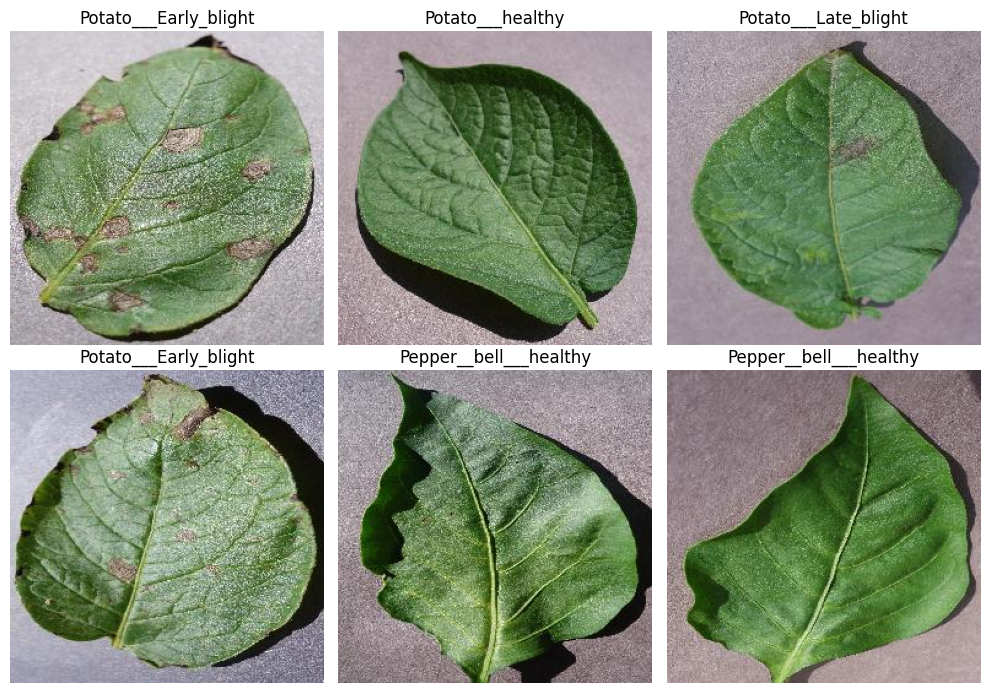

In [ ]:
## Sample images in the dataset
fig, axes = plt.subplots(2, 3, figsize=(10, 7))

for ax in axes.flat:
    cls = random.choice(subset_classes)
    cls_path = os.path.join(subset_dir, cls)
    img_name = random.choice(os.listdir(cls_path))
    img_path = os.path.join(cls_path, img_name)

    img = Image.open(img_path).convert("RGB")
    ax.imshow(img)
    ax.set_title(cls[:30])
    ax.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# =================
# Data Spliting
# =================
if os.path.exists(os.path.join(processed_dir, "train")):
    print("Split already exists. Skipping...")
else:
    splits = ["train", "val", "test"]

    for split in splits:
        os.makedirs(os.path.join(processed_dir, split), exist_ok=True)

    for class_name in os.listdir(subset_dir):
        class_path = os.path.join(subset_dir, class_name)
        images = os.listdir(class_path)

        random.shuffle(images)

        n = len(images)
        train_end = int(0.8 * n)
        val_end = int(0.9 * n)

        split_data = {
            "train": images[:train_end],
            "val": images[train_end:val_end],
            "test": images[val_end:]
        }

        for split, split_images in split_data.items():
            split_class_dir = os.path.join(processed_dir, split, class_name)
            os.makedirs(split_class_dir, exist_ok=True)

            for img in split_images:
                src = os.path.join(class_path, img)
                dst = os.path.join(split_class_dir, img)
                shutil.copy(src, dst)

    print("Data split complete.")

Split already exists. Skipping...


In [ ]:
# verify split counts
def count_images(base_dir):
    for split in ["train", "val", "test"]:
        print(f"\n--- {split.upper()} ---")
        split_path = os.path.join(base_dir, split)

        for cls in os.listdir(split_path):
            cls_path = os.path.join(split_path, cls)
            count = len(os.listdir(cls_path))
            print(f"{cls}: {count}")

count_images(processed_dir)


--- TRAIN ---
Pepper__bell___Bacterial_spot: 797
Pepper__bell___healthy: 1182
Potato___Early_blight: 800
Potato___Late_blight: 800
Potato___healthy: 121

--- VAL ---
Pepper__bell___Bacterial_spot: 100
Pepper__bell___healthy: 148
Potato___Early_blight: 100
Potato___Late_blight: 100
Potato___healthy: 15

--- TEST ---
Pepper__bell___Bacterial_spot: 100
Pepper__bell___healthy: 148
Potato___Early_blight: 100
Potato___Late_blight: 100
Potato___healthy: 16
